In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load the data

Same dataset as the from-scratch notebook: years of experience vs. salary.

In [52]:
salary_prediction = pd.read_csv('data/Salary_Data.csv')
salary_prediction.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


## Features and target¶
sklearn expects the features (X) as a 2D structure (a DataFrame, not a Series) even with a single column — hence the double brackets [['YearsExperience']]. The target (y) can stay 1D.

In [53]:
X = salary_prediction[['YearsExperience']]
y = salary_prediction['Salary']

## Train/test split
The data is split into a training set and test set. The model only ever sees the training set while fitting — the test set is used purely to check how well it generalises to data it hasn't seen. random_state=42 just makes the split reproducible.

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2 , random_state = 42)

## Fit the model
LinearRegression() finds the best-fit w (coefficient) and b (intercept) analytically.
No manual gradient descent loop needed.

In [55]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
print(f'weight {model.coef_[0]:.3f}')
print(f'bias {model.intercept_:.3f}')

weight 9423.815
bias 25321.583


## Predict on the test set

In [57]:
predict = model.predict(X_test)

## Evaluate¶
MAE, MSE and R², this time computed with sklearn's built-in metrics functions and measured on the test set, not the training set.

In [58]:
print('MAE', f'{mean_absolute_error(y_test, predict):.3f}')
print('MSE', f'{mean_squared_error(y_test, predict):.3f}')
print('R2', f'{r2_score(y_test, predict):.3f}')

MAE 6286.454
MSE 49830096.856
R2 0.902


## Visualize the fit

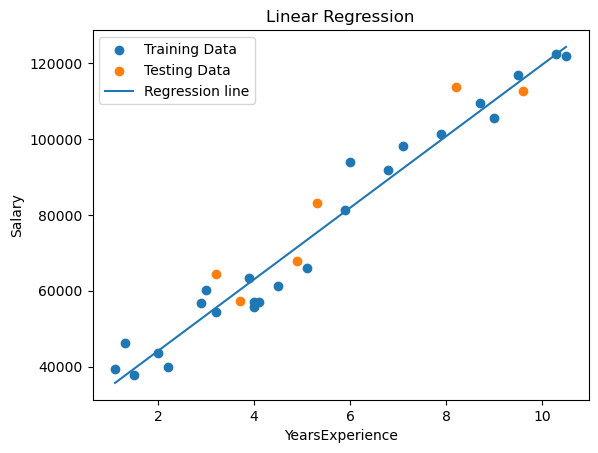

In [59]:
plt.scatter(X_train, y_train, label = "Training Data")
plt.scatter(X_test, y_test, label= "Testing Data")

X_line = pd.DataFrame({
    "YearsExperience": sorted(X["YearsExperience"])
})

y_line = model.predict(X_line)

plt.plot(X_line, y_line, label="Regression line")

plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Linear Regression")

plt.legend()
plt.show()